# Advocacy vs Inquiry -- How Teams Make (or Break) Security Decisions

Most security decisions are made by groups -- architecture review boards,
incident response teams, risk committees, compliance councils. The quality
of these decisions depends less on the expertise in the room than on *how*
the group processes information.

Two modes dominate group decision-making:

- **Advocacy:** Each participant argues for their position. The goal is to
  persuade. Evidence is marshaled in service of a pre-formed conclusion.
  The loudest, most senior, or most persistent voice wins.

- **Inquiry:** The group jointly explores the problem. The goal is to
  understand. Evidence is surfaced and weighed collectively. Disagreement
  is treated as information, not opposition.

The difference is not subtle. Advocacy feels productive -- people are
engaged, passionate, articulate. But it systematically degrades decision
quality. Just trying to convince the other of my point of view, there is
no inquiry. There is no genuine interest in solving the problem. It just
turns into a battle of positions, ego, and a plea to each other to see
my point of view.

This notebook quantifies the damage and models the fix.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from decision_security.synth import make_rng, sample
from decision_security.voi import evpi

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"

## 1. The Architecture Review Board Problem

A security architecture review board is deciding whether to adopt
zero-trust network access (ZTNA) or keep the existing VPN + firewall
perimeter model. The true risk reduction from ZTNA (relative to VPN)
is, say, 35% -- but nobody knows this exactly.

Five stakeholders sit at the table. Each has a different **position
strength** (how loudly they advocate) and a different **information
quality** (how much genuine signal their estimate carries).

| Stakeholder       | Position Strength | Info Quality | Notes |
|:------------------|:-----------------:|:------------:|:------|
| CISO              | 0.90              | 0.50         | Strong opinions, moderate data |
| Network Architect | 0.40              | 0.90         | Quiet, but has done the analysis |
| VP Engineering    | 0.80              | 0.30         | Loud, mostly concerned about migration cost |
| SOC Lead          | 0.50              | 0.70         | Has real incident data |
| Compliance Officer| 0.60              | 0.40         | Regulatory lens, limited technical depth |

In **advocacy mode**, the group decision is a weighted average where
weights are position strength -- the loudest voice dominates.

In **inquiry mode**, weights are information quality -- the most
informed voice contributes most.

In [2]:
# --- Architecture Review Board: Advocacy vs Inquiry ---

TRUE_RISK_REDUCTION = 0.35  # ZTNA reduces risk by 35% relative to VPN

stakeholders = {
    "CISO":              {"position_strength": 0.90, "info_quality": 0.50},
    "Network Architect":  {"position_strength": 0.40, "info_quality": 0.90},
    "VP Engineering":     {"position_strength": 0.80, "info_quality": 0.30},
    "SOC Lead":           {"position_strength": 0.50, "info_quality": 0.70},
    "Compliance Officer": {"position_strength": 0.60, "info_quality": 0.40},
}

names = list(stakeholders.keys())
pos_strength = np.array([stakeholders[n]["position_strength"] for n in names])
info_quality = np.array([stakeholders[n]["info_quality"] for n in names])

# Each stakeholder's estimate: drawn from N(true_value, sigma^2)
# where sigma is inversely proportional to info_quality
sigmas = 0.12 / info_quality  # higher quality = tighter estimate
estimates = np.clip(np.array([
    sample("normal", 1, rng=rng, loc=TRUE_RISK_REDUCTION, scale=s)[0]
    for s in sigmas
]), 0.0, 1.0)

# Advocacy mode: weight by position strength
adv_weights = pos_strength / pos_strength.sum()
advocacy_decision = np.dot(adv_weights, estimates)

# Inquiry mode: weight by information quality
inq_weights = info_quality / info_quality.sum()
inquiry_decision = np.dot(inq_weights, estimates)

print(f"True risk reduction from ZTNA: {TRUE_RISK_REDUCTION:.0%}")
print(f"{'':─<60}")
print(f"{'Stakeholder':<22} {'Estimate':>8} {'Adv Wt':>8} {'Inq Wt':>8}")
print(f"{'':─<22} {'':─>8} {'':─>8} {'':─>8}")
for i, name in enumerate(names):
    print(f"{name:<22} {estimates[i]:>8.1%} {adv_weights[i]:>8.1%} {inq_weights[i]:>8.1%}")
print(f"{'':─<60}")
print(f"{'Advocacy decision':<22} {advocacy_decision:>8.1%}")
print(f"{'Inquiry decision':<22} {inquiry_decision:>8.1%}")
print(f"{'True value':<22} {TRUE_RISK_REDUCTION:>8.1%}")
print(f"\nAdvocacy error: {abs(advocacy_decision - TRUE_RISK_REDUCTION):.1%}")
print(f"Inquiry error:  {abs(inquiry_decision - TRUE_RISK_REDUCTION):.1%}")

True risk reduction from ZTNA: 35%
────────────────────────────────────────────────────────────
Stakeholder            Estimate   Adv Wt   Inq Wt
────────────────────── ──────── ──────── ────────
CISO                      42.3%    28.1%    17.9%
Network Architect         21.1%    12.5%    32.1%
VP Engineering            65.0%    25.0%    10.7%
SOC Lead                  51.1%    15.6%    25.0%
Compliance Officer         0.0%    18.7%    14.3%
────────────────────────────────────────────────────────────
Advocacy decision         38.8%
Inquiry decision          34.1%
True value                35.0%

Advocacy error: 3.8%
Inquiry error:  0.9%


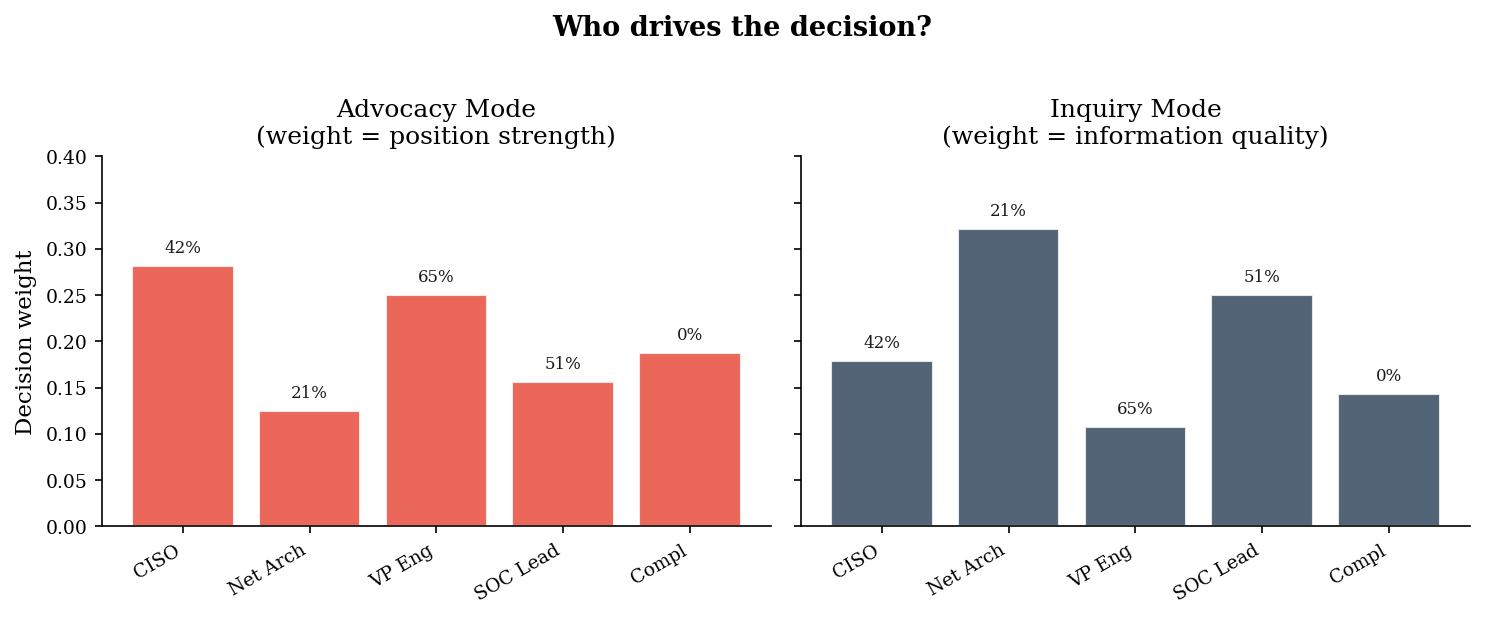


The Network Architect -- the person with the best data -- gets
12% weight in advocacy mode vs 32% in inquiry mode.
The VP Engineering -- the loudest voice with the least data -- gets
25% weight in advocacy mode vs 11% in inquiry mode.


In [3]:
# --- Bar chart: stakeholder contributions in each mode ---

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
x = np.arange(len(names))
short_names = ["CISO", "Net Arch", "VP Eng", "SOC Lead", "Compl"]

# Advocacy mode
contributions_adv = adv_weights * estimates
bars = axes[0].bar(x, adv_weights, color=ACCENT, alpha=0.85, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=30, ha="right")
axes[0].set_ylabel("Decision weight")
axes[0].set_title("Advocacy Mode\n(weight = position strength)")
axes[0].set_ylim(0, 0.40)

# Inquiry mode
axes[1].bar(x, inq_weights, color=DARK_BG, alpha=0.85, edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, rotation=30, ha="right")
axes[1].set_title("Inquiry Mode\n(weight = information quality)")

# Annotate estimates on both
for ax, wts in [(axes[0], adv_weights), (axes[1], inq_weights)]:
    for i in range(len(names)):
        ax.text(i, wts[i] + 0.01, f"{estimates[i]:.0%}",
                ha="center", va="bottom", fontsize=8, color=PRIMARY)

fig.suptitle("Who drives the decision?", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print(f"\nThe Network Architect -- the person with the best data -- gets")
print(f"{adv_weights[1]:.0%} weight in advocacy mode vs {inq_weights[1]:.0%} in inquiry mode.")
print(f"The VP Engineering -- the loudest voice with the least data -- gets")
print(f"{adv_weights[2]:.0%} weight in advocacy mode vs {inq_weights[2]:.0%} in inquiry mode.")

## 2. Information Pooling Failure

The "hidden profile" problem is one of the most replicated findings in
group decision research (Stasser & Titus, 1985). It works like this:

A team of 5 analysts is evaluating a threat. Collectively they have 15
pieces of evidence. But the evidence is distributed unevenly:

- **5 pieces are shared** -- everyone has seen them
- **10 pieces are unique** -- each analyst has 2 pieces nobody else has seen

Here is the trap: the shared evidence points toward Threat A. But the
unique evidence, taken together, overwhelmingly points toward Threat B.
The correct answer is B -- but only if you pool all 15 pieces.

In **advocacy mode**, people discuss what they already agree on. Shared
evidence dominates because it is easy to advocate for -- everyone nods.
Unique evidence gets dismissed as one person's opinion.

In **inquiry mode**, the group deliberately surfaces what each person
knows that others do not. Unique evidence enters the pool.

In [4]:
# --- Hidden Profile: Shared vs Unique Evidence ---

# Each piece of evidence shifts log-odds toward Threat A (positive) or B (negative)
# Shared evidence: all 5 pieces favor Threat A
shared_evidence = np.array([0.6, 0.5, 0.4, 0.7, 0.3])  # log-odds shifts toward A

# Unique evidence: 10 pieces across 5 analysts, mostly favoring Threat B
unique_evidence = {
    "Analyst 1": np.array([-0.8, -0.5]),
    "Analyst 2": np.array([-0.6, -0.9]),
    "Analyst 3": np.array([-0.4, -0.7]),
    "Analyst 4": np.array([-0.5, -0.3]),
    "Analyst 5": np.array([-0.6, -0.8]),
}

prior_log_odds = 0.0  # 50-50 prior

# Advocacy mode: only shared evidence gets discussed
advocacy_log_odds = prior_log_odds + shared_evidence.sum()
advocacy_prob_A = 1.0 / (1.0 + np.exp(-advocacy_log_odds))

# Inquiry mode: all evidence gets pooled
all_unique = np.concatenate(list(unique_evidence.values()))
inquiry_log_odds = prior_log_odds + shared_evidence.sum() + all_unique.sum()
inquiry_prob_A = 1.0 / (1.0 + np.exp(-inquiry_log_odds))

print("Evidence summary")
print(f"  Shared evidence (5 pieces):  total log-odds shift = {shared_evidence.sum():+.1f} (favors A)")
print(f"  Unique evidence (10 pieces): total log-odds shift = {all_unique.sum():+.1f} (favors B)")
print(f"  Combined:                    total log-odds shift = {shared_evidence.sum() + all_unique.sum():+.1f}")
print()
print(f"Advocacy mode (shared only):  P(Threat A) = {advocacy_prob_A:.1%}  -->  Team picks A")
print(f"Inquiry mode  (all pooled):   P(Threat A) = {inquiry_prob_A:.1%}  -->  Team picks B")
print(f"\nThe correct answer is Threat B. Advocacy gets it wrong.")

Evidence summary
  Shared evidence (5 pieces):  total log-odds shift = +2.5 (favors A)
  Unique evidence (10 pieces): total log-odds shift = -6.1 (favors B)
  Combined:                    total log-odds shift = -3.6

Advocacy mode (shared only):  P(Threat A) = 92.4%  -->  Team picks A
Inquiry mode  (all pooled):   P(Threat A) = 2.7%  -->  Team picks B

The correct answer is Threat B. Advocacy gets it wrong.


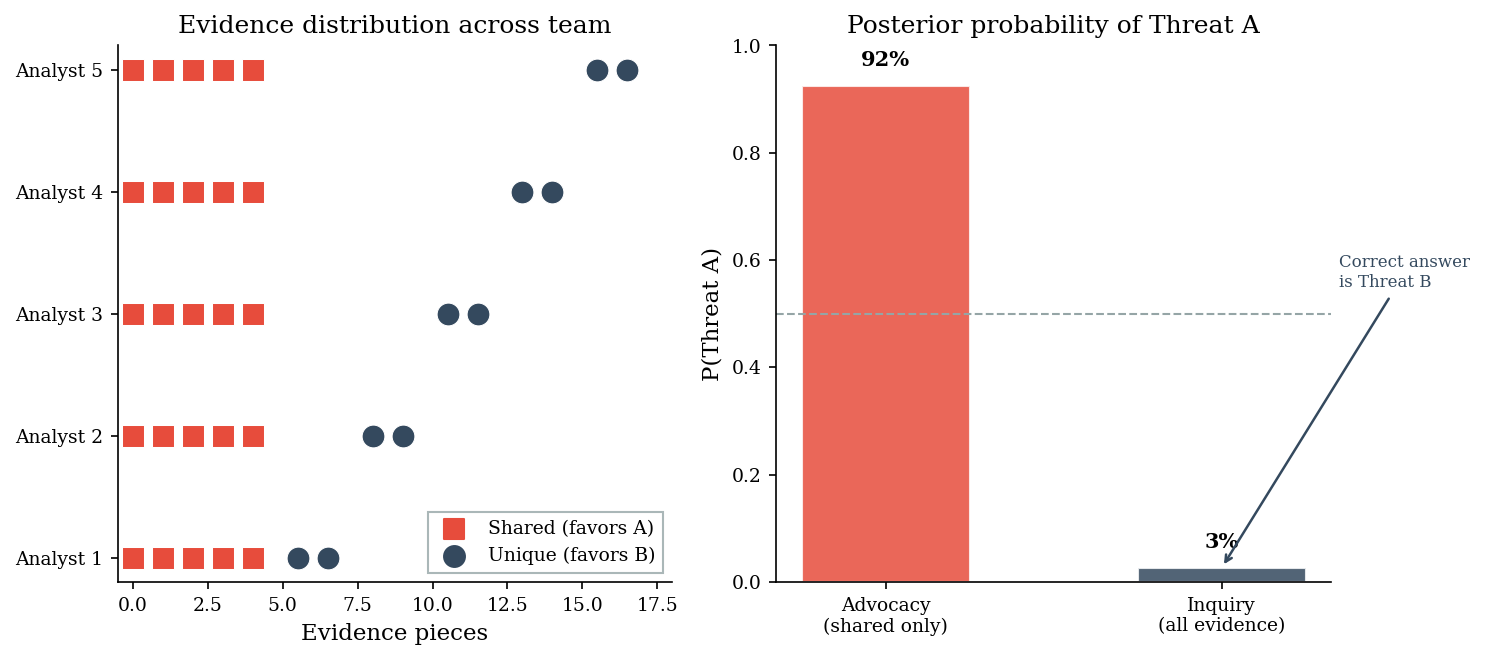

In [5]:
# --- Visualize shared vs unique evidence ---

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Left: evidence structure diagram
ax = axes[0]
analyst_names = list(unique_evidence.keys())
y_positions = np.arange(len(analyst_names))

# Draw shared evidence as a block
for i, y in enumerate(y_positions):
    # Shared pieces (everyone has these)
    for j in range(5):
        ax.scatter(j, y, s=120, c=ACCENT, marker="s", zorder=3,
                   edgecolors="white", linewidths=0.5)
    # Unique pieces (only this analyst has them)
    for j in range(2):
        ax.scatter(5.5 + j + i * 2.5, y, s=120, c=DARK_BG, marker="o",
                   zorder=3, edgecolors="white", linewidths=0.5)

ax.set_yticks(y_positions)
ax.set_yticklabels(analyst_names)
ax.set_xlim(-0.5, 18)
ax.set_xlabel("Evidence pieces")
ax.set_title("Evidence distribution across team")

# Legend
ax.scatter([], [], s=100, c=ACCENT, marker="s", label="Shared (favors A)")
ax.scatter([], [], s=100, c=DARK_BG, marker="o", label="Unique (favors B)")
ax.legend(loc="lower right", frameon=True, fancybox=False, edgecolor=LIGHT_GRAY)

# Right: posterior probability comparison
ax2 = axes[1]
modes = ["Advocacy\n(shared only)", "Inquiry\n(all evidence)"]
probs_A = [advocacy_prob_A, inquiry_prob_A]
colors = [ACCENT, DARK_BG]

bars = ax2.bar(modes, probs_A, color=colors, alpha=0.85, edgecolor="white", width=0.5)
ax2.axhline(0.5, color=LIGHT_GRAY, linestyle="--", linewidth=1, label="50% threshold")
ax2.set_ylabel("P(Threat A)")
ax2.set_ylim(0, 1.0)
ax2.set_title("Posterior probability of Threat A")

for bar, p in zip(bars, probs_A):
    ax2.text(bar.get_x() + bar.get_width() / 2, p + 0.03,
             f"{p:.0%}", ha="center", va="bottom", fontweight="bold")

ax2.annotate("Correct answer\nis Threat B", xy=(1, inquiry_prob_A),
             xytext=(1.35, 0.55), fontsize=8, color=DARK_BG,
             arrowprops=dict(arrowstyle="->", color=DARK_BG, lw=1.2))

fig.tight_layout()
plt.show()

## 3. The HiPPO Effect

HiPPO -- the Highest Paid Person's Opinion. In most security
organizations, the CISO or CTO has implicit veto power over group
decisions. Not because they are the most informed, but because they
are the most senior.

We model a recurring meeting where 4 analysts and 1 executive each
estimate breach probability. The executive's estimate is drawn from
the same distribution as the analysts' -- same accuracy, same
calibration. But in advocacy mode, the executive's opinion carries 5x
the weight of any single analyst.

We run 500 simulated meetings and compare mean squared error under
three weighting schemes:

- **Advocacy:** executive gets 5x weight
- **Inquiry:** equal weight for everyone
- **Optimal:** weight by actual track record (inverse variance)

In [6]:
# --- HiPPO Effect: 500 simulated meetings ---

N_MEETINGS = 500
N_ANALYSTS = 4
N_PARTICIPANTS = N_ANALYSTS + 1  # 4 analysts + 1 executive

# True breach probability varies each meeting (drawn from Beta)
true_probs = rng.beta(2, 8, size=N_MEETINGS)  # mean ~0.2

# Each participant's estimation noise (std dev)
# Analyst quality varies; executive is no better than average
analyst_sigmas = np.array([0.08, 0.06, 0.10, 0.07])  # 4 analysts
exec_sigma = 0.08  # executive -- same ballpark as analysts
all_sigmas = np.append(analyst_sigmas, exec_sigma)

# Weights under each mode
# Advocacy: executive gets 5x
adv_w = np.array([1, 1, 1, 1, 5], dtype=float)
adv_w /= adv_w.sum()

# Inquiry: equal weight
inq_w = np.ones(N_PARTICIPANTS) / N_PARTICIPANTS

# Optimal: inverse-variance weighting
opt_w = 1.0 / all_sigmas**2
opt_w /= opt_w.sum()

errors_advocacy = np.zeros(N_MEETINGS)
errors_inquiry = np.zeros(N_MEETINGS)
errors_optimal = np.zeros(N_MEETINGS)

for m in range(N_MEETINGS):
    truth = true_probs[m]
    # Each participant's estimate: truth + noise, clipped to [0,1]
    noise = rng.normal(0, all_sigmas)
    estimates = np.clip(truth + noise, 0, 1)

    # Weighted decisions
    dec_adv = np.dot(adv_w, estimates)
    dec_inq = np.dot(inq_w, estimates)
    dec_opt = np.dot(opt_w, estimates)

    errors_advocacy[m] = (dec_adv - truth) ** 2
    errors_inquiry[m] = (dec_inq - truth) ** 2
    errors_optimal[m] = (dec_opt - truth) ** 2

print(f"Mean Squared Error across {N_MEETINGS} meetings:")
print(f"  Advocacy (HiPPO 5x):  {errors_advocacy.mean():.5f}")
print(f"  Inquiry (equal wt):   {errors_inquiry.mean():.5f}")
print(f"  Optimal (inv-var):    {errors_optimal.mean():.5f}")
print(f"\nAdvocacy MSE is {errors_advocacy.mean() / errors_inquiry.mean():.1f}x worse than inquiry.")

Mean Squared Error across 500 meetings:
  Advocacy (HiPPO 5x):  0.00209
  Inquiry (equal wt):   0.00110
  Optimal (inv-var):    0.00098

Advocacy MSE is 1.9x worse than inquiry.


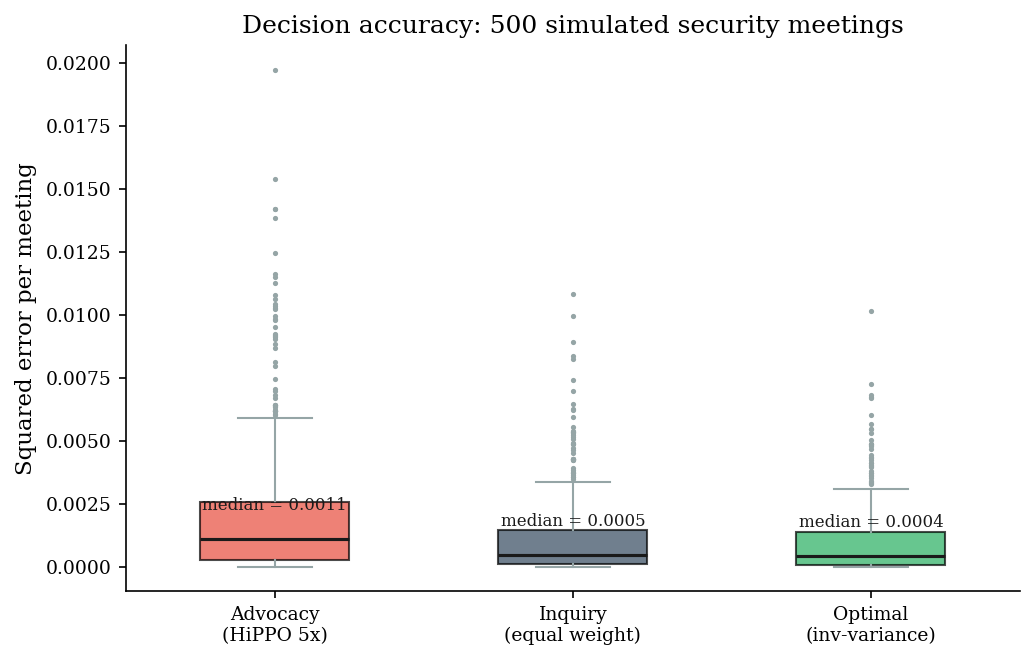

In [7]:
# --- Box plot of squared errors across 500 meetings ---

fig, ax = plt.subplots(figsize=(7, 4.5))

data = [errors_advocacy, errors_inquiry, errors_optimal]
tick_labels = ["Advocacy\n(HiPPO 5x)", "Inquiry\n(equal weight)", "Optimal\n(inv-variance)"]
colors_bp = [ACCENT, DARK_BG, "#27AE60"]

bp = ax.boxplot(data, tick_labels=tick_labels, patch_artist=True, widths=0.5,
                medianprops=dict(color=PRIMARY, linewidth=1.5),
                whiskerprops=dict(color=LIGHT_GRAY),
                capprops=dict(color=LIGHT_GRAY),
                flierprops=dict(marker=".", markersize=3, markerfacecolor=LIGHT_GRAY,
                                markeredgecolor=LIGHT_GRAY))

for patch, color in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Squared error per meeting")
ax.set_title("Decision accuracy: 500 simulated security meetings")

# Annotate medians
medians = [np.median(d) for d in data]
for i, med in enumerate(medians):
    ax.text(i + 1, med + 0.001, f"median = {med:.4f}",
            ha="center", va="bottom", fontsize=8, color=PRIMARY)

fig.tight_layout()
plt.show()

## 4. Constructive Disagreement Protocol

If advocacy is the disease, structured inquiry is the treatment. The
protocol is simple and free:

1. **Before the meeting:** Each person writes their estimate
   independently. No discussion, no Slack threads, no hallway
   pre-alignment. This prevents anchoring.

2. **Start of meeting:** All estimates are revealed simultaneously
   (e.g., on sticky notes, or via anonymous poll). No serial
   disclosure.

3. **Discussion:** Focus on the *largest disagreements* first. If
   everyone agrees, there is nothing to discuss. If two people are
   far apart, that is where the information lives -- one of them
   knows something the other does not.

4. **After discussion:** Each person updates their estimate
   independently. No group vote, no consensus pressure.

We compare this protocol against **serial discussion**, where each
person states their estimate one at a time (and each subsequent
person anchors on what they just heard).

In [8]:
# --- Structured Protocol vs Serial Discussion ---

N_ROUNDS = 200
N_PEOPLE = 5
ANCHOR_STRENGTH = 0.50  # how much each person anchors on the previous speaker

true_values = sample("normal", N_ROUNDS, rng=rng, loc=0.30, scale=0.10)
true_values = np.clip(true_values, 0.05, 0.95)

individual_sigma = 0.12  # each person's independent noise

structured_decisions = np.zeros(N_ROUNDS)
serial_decisions = np.zeros(N_ROUNDS)

for r in range(N_ROUNDS):
    truth = true_values[r]

    # --- Structured protocol: independent estimates, then average ---
    independent_estimates = np.clip(
        truth + rng.normal(0, individual_sigma, size=N_PEOPLE), 0, 1
    )
    structured_decisions[r] = independent_estimates.mean()

    # --- Serial discussion: each person anchors on the previous ---
    # First speaker sets the anchor. Each subsequent speaker blends
    # their own signal with the *running group mean so far* (not just
    # the previous speaker), modeling cumulative conformity pressure.
    serial_estimates = np.zeros(N_PEOPLE)
    for p in range(N_PEOPLE):
        own_signal = truth + rng.normal(0, individual_sigma)
        if p == 0:
            serial_estimates[p] = np.clip(own_signal, 0, 1)
        else:
            group_anchor = serial_estimates[:p].mean()
            anchored = (1 - ANCHOR_STRENGTH) * own_signal + ANCHOR_STRENGTH * group_anchor
            serial_estimates[p] = np.clip(anchored, 0, 1)
    serial_decisions[r] = serial_estimates.mean()

# Compute errors
structured_errors = (structured_decisions - true_values) ** 2
serial_errors = (serial_decisions - true_values) ** 2

print(f"Results across {N_ROUNDS} simulated rounds:")
print(f"  Structured protocol MSE: {structured_errors.mean():.5f}")
print(f"  Serial discussion MSE:   {serial_errors.mean():.5f}")
print(f"  Serial is {serial_errors.mean() / structured_errors.mean():.1f}x worse")
print(f"\n  Structured std of decisions: {structured_decisions.std():.4f}")
print(f"  Serial std of decisions:     {serial_decisions.std():.4f}")
print(f"\nAnchoring reduces effective diversity of opinion. The first")
print(f"speaker's error propagates through the entire group.")

Results across 200 simulated rounds:
  Structured protocol MSE: 0.00273
  Serial discussion MSE:   0.00420
  Serial is 1.5x worse

  Structured std of decisions: 0.1143
  Serial std of decisions:     0.1214

Anchoring reduces effective diversity of opinion. The first
speaker's error propagates through the entire group.


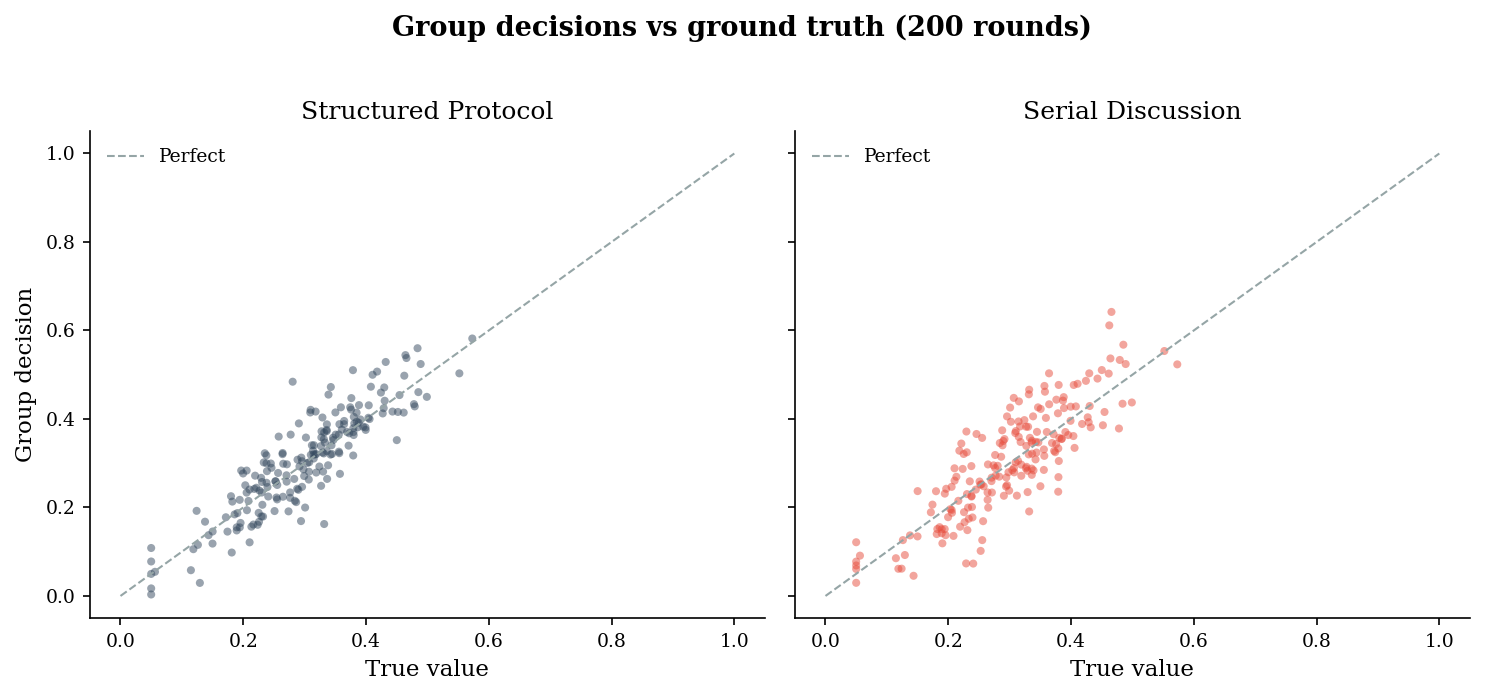

The structured protocol shows tighter clustering around the
diagonal -- the group converges closer to truth when estimates
are made independently before discussion.


In [9]:
# --- Scatter: decision vs truth for both protocols ---

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

for ax, decisions, title, color in [
    (axes[0], structured_decisions, "Structured Protocol", DARK_BG),
    (axes[1], serial_decisions, "Serial Discussion", ACCENT),
]:
    ax.scatter(true_values, decisions, s=15, alpha=0.5, color=color, edgecolors="none")
    ax.plot([0, 1], [0, 1], color=LIGHT_GRAY, linestyle="--", linewidth=1, label="Perfect")
    ax.set_xlabel("True value")
    ax.set_title(title)
    ax.legend(loc="upper left", frameon=False)

axes[0].set_ylabel("Group decision")

fig.suptitle("Group decisions vs ground truth (200 rounds)",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print("The structured protocol shows tighter clustering around the")
print("diagonal -- the group converges closer to truth when estimates")
print("are made independently before discussion.")

## 5. When Advocacy Is Appropriate

Advocacy is not always bad. If one team member has ground truth -- they
found the root cause in the logs, they have the forensic evidence, they
know the answer -- then advocating for the correct conclusion is
efficient. The problem is when advocacy *substitutes* for inquiry:
when nobody has ground truth and everyone is arguing their prior.

This gives us a 2x2 matrix:

|                     | **Advocacy**                   | **Inquiry**                        |
|:--------------------|:-------------------------------|:-----------------------------------|
| **High Information** | Effective (expert persuades)  | Slightly slower but also effective |
| **Low Information**  | Dangerous (loudest wins)      | Productive (surfaces assumptions)  |

In [10]:
# --- Simulate the 2x2: MSE under each combination ---

N_SIM = 1000
N_TEAM = 5

# High information: one person has very low noise (sigma=0.02),
# others have moderate noise (sigma=0.15)
# Low information: everyone has high noise (sigma=0.20)

results = {}

for info_level, sigmas_vec in [
    ("High Info", np.array([0.02, 0.15, 0.15, 0.15, 0.15])),
    ("Low Info", np.array([0.20, 0.20, 0.20, 0.20, 0.20])),
]:
    for mode, weights in [
        ("Advocacy", np.array([5, 1, 1, 1, 1], dtype=float)),  # person 0 is loudest
        ("Inquiry", np.ones(N_TEAM, dtype=float)),
    ]:
        w = weights / weights.sum()
        truths = rng.beta(3, 7, size=N_SIM)
        se = np.zeros(N_SIM)
        for i in range(N_SIM):
            ests = np.clip(truths[i] + rng.normal(0, sigmas_vec), 0, 1)
            dec = np.dot(w, ests)
            se[i] = (dec - truths[i]) ** 2
        results[(info_level, mode)] = se.mean()

print(f"{'':─<50}")
print(f"{'MSE by (Information Level, Decision Mode)':^50}")
print(f"{'':─<50}")
print(f"{'':20} {'Advocacy':>14} {'Inquiry':>14}")
print(f"{'High Info':20} {results[('High Info', 'Advocacy')]:>14.5f} {results[('High Info', 'Inquiry')]:>14.5f}")
print(f"{'Low Info':20} {results[('Low Info', 'Advocacy')]:>14.5f} {results[('Low Info', 'Inquiry')]:>14.5f}")
print(f"{'':─<50}")

──────────────────────────────────────────────────
    MSE by (Information Level, Decision Mode)     
──────────────────────────────────────────────────
                           Advocacy        Inquiry
High Info                   0.00112        0.00319
Low Info                    0.01294        0.00656
──────────────────────────────────────────────────


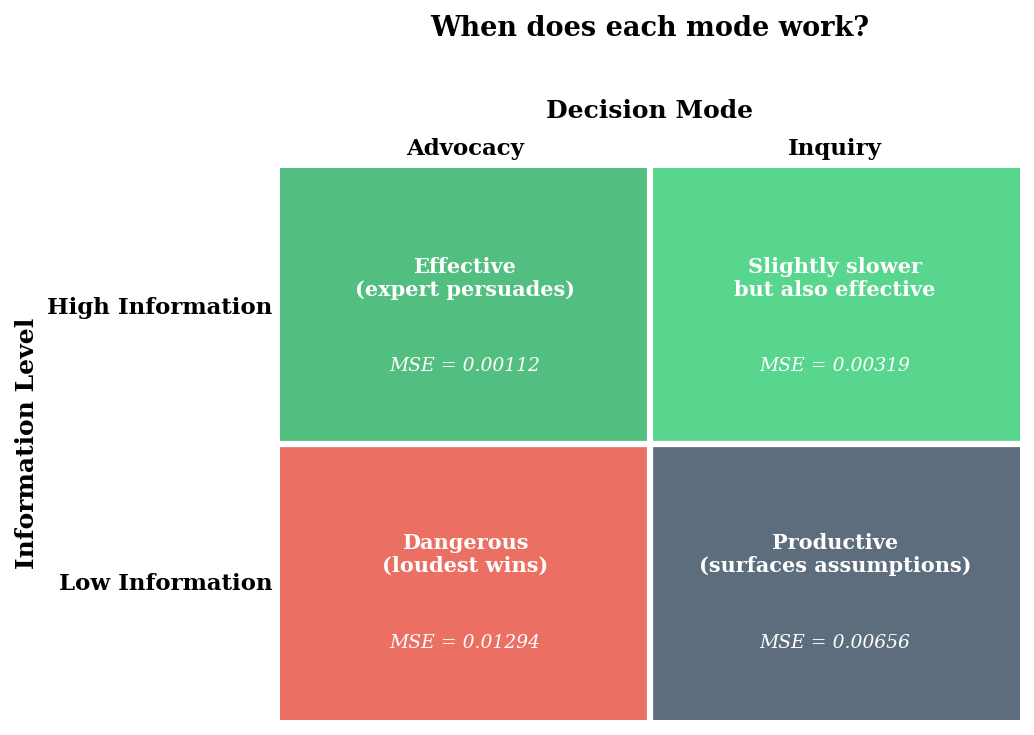

In [11]:
# --- 2x2 Matrix visualization ---

fig, ax = plt.subplots(figsize=(7, 5))

# Cell definitions: (row, col, label, mse, color, text_color)
cells = [
    (0, 0, "Effective\n(expert persuades)",
     results[("High Info", "Advocacy")], "#27AE60", "white"),
    (0, 1, "Slightly slower\nbut also effective",
     results[("High Info", "Inquiry")], "#2ECC71", "white"),
    (1, 0, "Dangerous\n(loudest wins)",
     results[("Low Info", "Advocacy")], ACCENT, "white"),
    (1, 1, "Productive\n(surfaces assumptions)",
     results[("Low Info", "Inquiry")], DARK_BG, "white"),
]

for row, col, label, mse, color, tc in cells:
    rect = plt.Rectangle((col, 1 - row - 1), 1, 1, facecolor=color, alpha=0.8)
    ax.add_patch(rect)
    ax.text(col + 0.5, 1 - row - 0.40, label,
            ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
    ax.text(col + 0.5, 1 - row - 0.72, f"MSE = {mse:.5f}",
            ha="center", va="center", fontsize=9, color=tc, fontstyle="italic")

# Axes labels
ax.set_xlim(0, 2)
ax.set_ylim(-1, 1)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Advocacy", "Inquiry"], fontsize=11, fontweight="bold")
ax.set_yticks([-0.5, 0.5])
ax.set_yticklabels(["Low Information", "High Information"], fontsize=11, fontweight="bold")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.set_xlabel("Decision Mode", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Information Level", fontsize=12, fontweight="bold")

# Remove all spines
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

# Grid lines between cells
ax.axhline(0, color="white", linewidth=3)
ax.axvline(1, color="white", linewidth=3)

ax.set_title("When does each mode work?", fontsize=13, fontweight="bold", pad=30)
fig.tight_layout()
plt.show()

## 6. Pitfalls

**Advocacy feels productive but it is a battle of positions.** The room
is energized, people are passionate, arguments are sharp. It feels
like good decision-making. It is not. It is a contest where the winner
is determined by rhetorical skill, seniority, and stamina -- not by
evidence quality.

**Shared information crowds out unique information.** The hidden profile
effect means that groups systematically over-discuss what everyone
already knows and under-discuss what only one person knows. The more
people agree on something, the more airtime it gets -- even when the
disagreements contain all the decision-relevant signal.

**Seniority does not equal signal quality.** The CISO has broader
context but not necessarily better data about *this specific* decision.
The SOC analyst who pulled the logs may have the most informative
estimate in the room. HiPPO weighting systematically discounts the
people closest to the evidence.

**Pre-commitment is the single cheapest debiasing technique.**
Having each person write down their estimate before discussion costs
zero dollars and five minutes. It eliminates anchoring, reduces
conformity pressure, and surfaces the true distribution of beliefs
in the room.

**Inquiry requires psychological safety.** People will not surface
unique information if they fear being judged for disagreeing with
the group or contradicting the boss. The organizational precondition
for inquiry is that being wrong is tolerated -- even expected -- as
the cost of honest exploration.

> "There is no genuine interest in solving the problem. It just turns
> into a battle of positions, ego, and a plea to each other to see
> my point of view."